In [2]:
import pandas as pd

In [4]:
from google.colab import files
arquivos = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv


In [5]:
pedidos = pd.read_csv("olist_orders_dataset.csv")
clientes = pd.read_csv("olist_customers_dataset.csv")

In [6]:
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
pedidos.shape

(99441, 8)

In [9]:
pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [10]:
pedidos["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [11]:
colunas_data = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for coluna in colunas_data:
    pedidos[coluna] = pd.to_datetime(pedidos[coluna])

In [12]:
pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](3), object(5)
memory usage: 6.1+ MB


In [13]:
duplicados = pedidos.duplicated(subset="order_id").sum()
print("Pedidos duplicados:", duplicados)

Pedidos duplicados: 0


In [14]:
pedidos.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [15]:
antes = len(pedidos)

pedidos = pedidos[
    (pedidos["order_status"] == "delivered")
    & (pedidos["order_delivered_customer_date"].notna())
]

print("Pedidos antes:", antes)
print("Pedidos removidos:", antes - len(pedidos))
print("Pedidos restantes:", len(pedidos))

Pedidos antes: 99441
Pedidos removidos: 2971
Pedidos restantes: 96470


In [16]:
dados = pedidos.merge(
    clientes[["customer_id", "customer_state"]],
    on="customer_id",
    how="left",
)

dados = dados.rename(columns={"customer_state": "estado"})

In [17]:
dados["estado"].isna().sum()

np.int64(0)

In [18]:
dados["dias_entrega"] = (
    dados["order_delivered_customer_date"] - dados["order_purchase_timestamp"]
).dt.days

dados["atrasado"] = (
    dados["order_delivered_customer_date"] > dados["order_estimated_delivery_date"]
)

dados["situacao_prazo"] = dados["atrasado"].map({True: "Atrasado", False: "No prazo"})

In [19]:
dados[["order_id", "estado", "dias_entrega", "situacao_prazo"]].head()

,order_id,estado,dias_entrega,situacao_prazo
0,e481f51cbdc54678b7cc49136f2d6af7,SP,8,No prazo
1,53cdb2fc8bc7dce0b6741e2150273451,BA,13,No prazo
2,47770eb9100c2d0c44946d9cf07ec65d,GO,9,No prazo
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,13,No prazo
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,2,No prazo


In [20]:
dados["dias_entrega"].describe()

,dias_entrega
count,96470.000000
mean,12.093604
std,9.551380
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [21]:
print("Entregas com prazo negativo:", (dados["dias_entrega"] < 0).sum())
print("Entregas acima de 100 dias:", (dados["dias_entrega"] > 100).sum())

Entregas com prazo negativo: 0
Entregas acima de 100 dias: 63


In [22]:
dados.to_csv("pedidos_limpos.csv", index=False)
files.download("pedidos_limpos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
prazo_estado = (
    dados.groupby("estado")["dias_entrega"]
    .mean()
    .round(1)
    .sort_values(ascending=False)
)
prazo_estado

,dias_entrega
estado,
RR,29.0
AP,26.7
AM,26.0
AL,24.0
PA,23.3
MA,21.1
SE,21.0
CE,20.8
AC,20.6


In [24]:
atraso_estado = (
    dados.groupby("estado")["atrasado"]
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)
atraso_estado

,atrasado
estado,
AL,23.9
MA,19.7
PI,16.0
CE,15.3
SE,15.2
BA,14.0
RJ,13.5
TO,12.8
PA,12.4


In [25]:
prazo_medio_geral = round(dados["dias_entrega"].mean(), 1)
prazo_mediano_geral = dados["dias_entrega"].median()
atraso_geral = round(dados["atrasado"].mean() * 100, 1)
inicio = dados["order_purchase_timestamp"].min().date()
fim = dados["order_purchase_timestamp"].max().date()

print("Prazo médio geral:", prazo_medio_geral, "dias")
print("Prazo mediano geral:", prazo_mediano_geral, "dias")
print("Percentual de atraso geral:", atraso_geral, "%")
print("Período dos dados:", inicio, "a", fim)
print("Pedidos analisados:", len(dados))

Prazo médio geral: 12.1 dias
Prazo mediano geral: 10.0 dias
Percentual de atraso geral: 8.1 %
Período dos dados: 2016-09-15 a 2018-08-29
Pedidos analisados: 96470


<Axes: title={'center': 'Prazo médio de entrega por estado (dias)'}, xlabel='estado'>

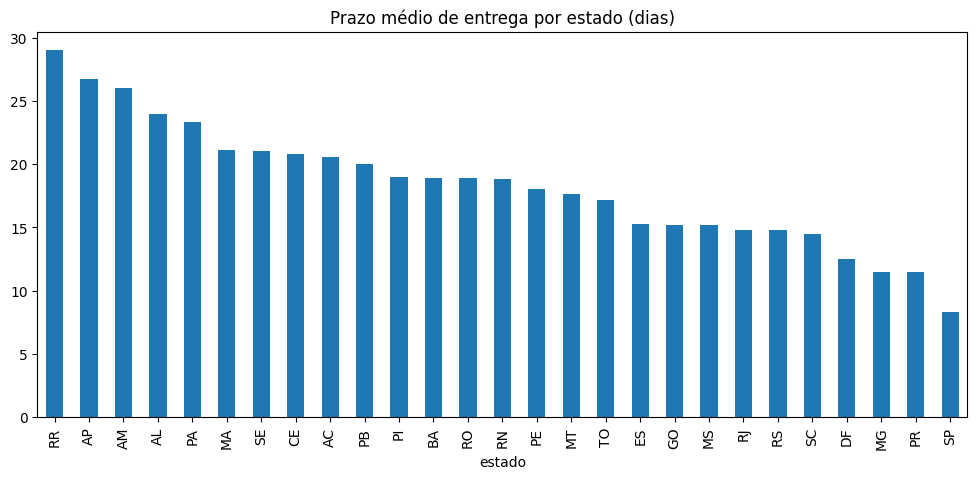

In [26]:
prazo_estado.plot(
    kind="bar",
    figsize=(12, 5),
    title="Prazo médio de entrega por estado (dias)",
)

In [27]:
print("Estado com maior prazo:", prazo_estado.index[0], prazo_estado.iloc[0], "dias")
print("Estado com menor prazo:", prazo_estado.index[-1], prazo_estado.iloc[-1], "dias")

Estado com maior prazo: RR 29.0 dias
Estado com menor prazo: SP 8.3 dias


In [28]:
nomes_estados = {
    "AC": "Acre", "AL": "Alagoas", "AP": "Amapá", "AM": "Amazonas",
    "BA": "Bahia", "CE": "Ceará", "DF": "Distrito Federal",
    "ES": "Espírito Santo", "GO": "Goiás", "MA": "Maranhão",
    "MT": "Mato Grosso", "MS": "Mato Grosso do Sul", "MG": "Minas Gerais",
    "PA": "Pará", "PB": "Paraíba", "PR": "Paraná", "PE": "Pernambuco",
    "PI": "Piauí", "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul", "RO": "Rondônia", "RR": "Roraima",
    "SC": "Santa Catarina", "SP": "São Paulo", "SE": "Sergipe", "TO": "Tocantins",
}

In [29]:
linhas = []
for sigla in prazo_estado.index:
    nome = nomes_estados[sigla]
    frase = (
        f"Para o estado de {nome} ({sigla}), o prazo médio de entrega é de "
        f"{prazo_estado[sigla]} dias e cerca de {atraso_estado[sigla]}% "
        f"dos pedidos chegam depois da data estimada."
    )
    linhas.append(frase)

texto_estados = "\n\n".join(linhas)
print(texto_estados)

Para o estado de Roraima (RR), o prazo médio de entrega é de 29.0 dias e cerca de 12.2% dos pedidos chegam depois da data estimada.

Para o estado de Amapá (AP), o prazo médio de entrega é de 26.7 dias e cerca de 4.5% dos pedidos chegam depois da data estimada.

Para o estado de Amazonas (AM), o prazo médio de entrega é de 26.0 dias e cerca de 4.1% dos pedidos chegam depois da data estimada.

Para o estado de Alagoas (AL), o prazo médio de entrega é de 24.0 dias e cerca de 23.9% dos pedidos chegam depois da data estimada.

Para o estado de Pará (PA), o prazo médio de entrega é de 23.3 dias e cerca de 12.4% dos pedidos chegam depois da data estimada.

Para o estado de Maranhão (MA), o prazo médio de entrega é de 21.1 dias e cerca de 19.7% dos pedidos chegam depois da data estimada.

Para o estado de Sergipe (SE), o prazo médio de entrega é de 21.0 dias e cerca de 15.2% dos pedidos chegam depois da data estimada.

Para o estado de Ceará (CE), o prazo médio de entrega é de 20.8 dias e cer

In [30]:
texto_geral = (
    f"O prazo médio geral de entrega é de {prazo_medio_geral} dias "
    f"e o prazo mediano é de {prazo_mediano_geral} dias. "
    f"Cerca de {atraso_geral}% dos pedidos chegam depois da data estimada. "
    f"Foram analisados {len(dados)} pedidos entregues, feitos entre {inicio} e {fim}."
)
print(texto_geral)

O prazo médio geral de entrega é de 12.1 dias e o prazo mediano é de 10.0 dias. Cerca de 8.1% dos pedidos chegam depois da data estimada. Foram analisados 96470 pedidos entregues, feitos entre 2016-09-15 e 2018-08-29.
